In [49]:
#importing the libraries 
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings('ignore')

In [50]:
#Now loading the dataset 
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)
churn_df.sample(5)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
35,65.0,65.0,27.0,128.0,3.0,24.0,0.0,1.0,0.0,21.20,...,0.0,0.0,1.0,1.0,0.0,3.054,3.178,4.852,3.0,0.0
180,56.0,53.0,23.0,100.0,5.0,14.0,1.0,1.0,0.0,14.15,...,0.0,1.0,0.0,0.0,1.0,2.650,3.240,4.605,2.0,0.0
94,55.0,52.0,22.0,127.0,1.0,28.0,0.0,1.0,0.0,7.05,...,0.0,0.0,0.0,0.0,1.0,1.953,3.240,4.844,2.0,0.0
194,57.0,60.0,20.0,14.0,2.0,27.0,0.0,1.0,0.0,16.10,...,0.0,0.0,1.0,1.0,0.0,2.779,2.639,2.639,3.0,0.0
140,8.0,42.0,2.0,129.0,4.0,17.0,0.0,0.0,0.0,6.10,...,0.0,1.0,0.0,1.0,1.0,1.808,3.240,4.860,1.0,0.0


In [51]:
#GETING TO KNOW SOME INFORMATION OF THE DATASET 
display(churn_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float6

None

In [52]:
churn_df.describe()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000,200.000000,200.000000,200.00000,...,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,35.505000,41.165000,11.650000,75.130000,2.82500,10.22500,0.425000,0.705000,0.290000,11.78925,...,0.275000,0.440000,0.45500,0.460000,0.440000,2.193285,3.229185,3.951015,2.475000,0.290000
std,21.640971,13.076803,10.158419,128.430468,1.28555,8.95743,0.495584,0.457187,0.454901,9.88725,...,0.447635,0.497633,0.49922,0.499648,0.497633,0.731282,0.281019,0.752553,1.079445,0.454901
min,1.000000,19.000000,0.000000,9.000000,1.00000,0.00000,0.000000,0.000000,0.000000,1.10000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.095000,1.749000,2.197000,1.000000,0.000000
25%,16.750000,31.000000,3.000000,31.000000,2.00000,3.00000,0.000000,0.000000,0.000000,5.53750,...,0.000000,0.000000,0.00000,0.000000,0.000000,1.711750,3.226500,3.434000,2.000000,0.000000
50%,33.500000,40.000000,9.000000,48.000000,3.00000,7.50000,0.000000,1.000000,0.000000,8.25000,...,0.000000,0.000000,0.00000,0.000000,0.000000,2.110000,3.240000,3.871000,2.000000,0.000000
75%,55.250000,51.000000,18.000000,80.000000,4.00000,17.00000,1.000000,1.000000,1.000000,14.30000,...,1.000000,1.000000,1.00000,1.000000,1.000000,2.660000,3.240000,4.382000,3.000000,1.000000
max,72.000000,76.000000,48.000000,1668.000000,5.00000,44.00000,1.000000,1.000000,1.000000,62.30000,...,1.000000,1.000000,1.00000,1.000000,1.000000,4.132000,4.227000,7.419000,4.000000,1.000000


In [53]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'churn']]

churn_df['churn'] = churn_df['churn'].astype('int')

churn_df

,tenure,age,address,income,ed,employ,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0
...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0
196,34.0,23.0,3.0,24.0,1.0,7.0,0
197,6.0,32.0,10.0,47.0,1.0,10.0,0
198,24.0,30.0,0.0,25.0,4.0,5.0,1


In [54]:
churn_df.describe()

,tenure,age,address,income,ed,employ,churn
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000
mean,35.505000,41.165000,11.650000,75.130000,2.82500,10.22500,0.290000
std,21.640971,13.076803,10.158419,128.430468,1.28555,8.95743,0.454901
min,1.000000,19.000000,0.000000,9.000000,1.00000,0.00000,0.000000
25%,16.750000,31.000000,3.000000,31.000000,2.00000,3.00000,0.000000
50%,33.500000,40.000000,9.000000,48.000000,3.00000,7.50000,0.000000
75%,55.250000,51.000000,18.000000,80.000000,4.00000,17.00000,1.000000
max,72.000000,76.000000,48.000000,1668.000000,5.00000,44.00000,1.000000


In [55]:
#Data preprocessing stage

In [56]:
#X = churn_df.iloc[:,[0,1,2,3,4,5]].to_numpy()

In [57]:
#X

In [58]:
X = np.asarray(churn_df[['tenure','age','address','income','ed','employ']])

In [59]:
X[:5]

array([[ 11.,  33.,   7., 136.,   5.,   5.],
       [ 33.,  33.,  12.,  33.,   2.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.],
       [ 38.,  35.,   5.,  76.,   2.,  10.],
       [  7.,  35.,  14.,  80.,   2.,  15.]])

In [60]:
"""
y = churn_df.iloc[:,[6]].to_numpy().flatten()
y[0:5]
The flatten means to convert multiple dimension array to 1D array
for this project i will be using the one in the course book 
"""

'\ny = churn_df.iloc[:,[6]].to_numpy().flatten()\ny[0:5]\nThe flatten means to convert multiple dimension array to 1D array\nfor this project i will be using the one in the course book \n'

In [61]:
y = np.asarray(churn_df['churn'])
y[0:5]

array([1, 1, 0, 0, 0])

In [71]:
#Standardizing the dataset to make the mean of each feature be Zero and the stsndard deviation be 1
scaler = StandardScaler()

std_X = scaler.fit_transform(X)
std_X[:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472]])

In [80]:
#Splitting the dataset into training and testing set 
X_train, X_test, y_train, y_test = train_test_split(std_X,y, test_size = 0.3, random_state = 42)

In [81]:
#So now I am about to build the logistic regression classifier modeling from the scikit-Learn
LR = LogisticRegression()
LR.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [83]:
#Making prediction on the test set
yhat = LR.predict(X_test)
yhat[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [90]:
#Now i want to know how confindent the model is or the probability of each class
yhat_prob = LR.predict_proba(X_test)
yhat1[:10]

array([[0.68309201, 0.31690799],
       [0.20792019, 0.79207981],
       [0.812221  , 0.187779  ],
       [0.80302783, 0.19697217],
       [0.83588029, 0.16411971],
       [0.35220646, 0.64779354],
       [0.98857718, 0.01142282],
       [0.75759218, 0.24240782],
       [0.65249195, 0.34750805],
       [0.94891166, 0.05108834]])

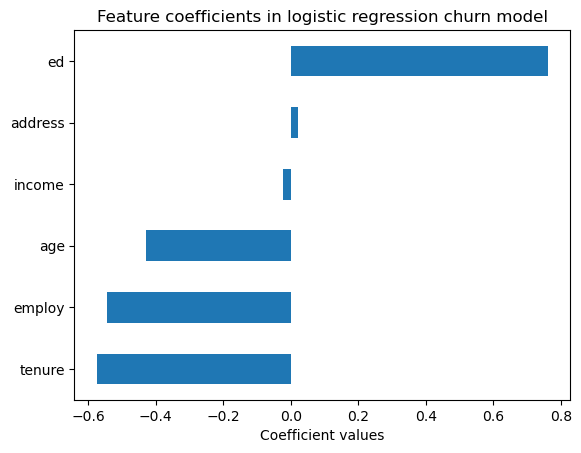

In [91]:
#Examine what role each input feature has to play inthe prediction of class 1 
coefficients = pd.Series(LR.coef_[0],index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature coefficients in logistic regression churn model")
plt.xlabel("Coefficient values")
plt.show()

In [92]:
#Let Now check the performance evaluation of the model
log_loss(y_test,yhat_prob)

0.5509183266208024